# JOILang Strong Compression End-to-End Notebook

A100/A6000 공통 실행용으로 처음부터 다시 구성한 notebook입니다.

구성:
1. 서버/경로 자동 감지
2. `run_ga_search.py` 최신 CLI flag 확인
3. 최신 `run_ga_all_categories()` wrapper 정의
4. 모델/CUDA/OpenAI key 확인
5. cloudless smoke
6. real cloud advisor smoke
7. advisor parsing/recording/fallback 검증 gate
8. full fair run 실행 셀
9. result discovery / schema normalization
10. 논문 확인용 main table / model-level DET/pass/token/latency figure 저장

기본값은 안전하게 smoke 중심입니다. Full fair run은 gate 통과 후 `RUN_FULL_FAIR=True`로 바꿔 실행하세요.

In [14]:
# ============================================================
# 0. TOP CONFIG
# ============================================================

from pathlib import Path
import os, sys, re, json, time, math, getpass, traceback, subprocess, inspect
from datetime import datetime
import pandas as pd
import numpy as np

try:
    from IPython.display import display
except Exception:
    display = print

SERVER_PRESET_OVERRIDE = None
REPO_OVERRIDE = None
PYTHON_OVERRIDE = "/root/llm/je/bin/python"
LOCAL_MODEL_BASE_OVERRIDE = None

SERVER_CANDIDATES = [
    {
        "server": "A100_SET_B",
        "repo": Path("/root/llm/JOILang-Server"),
        "python_candidates": [Path("/root/llm/je/bin/python"), Path("/root/llm/je/bin/python3.10"), Path(sys.executable)],
        "local_model_base": Path("/root/llm/local_models"),
    },
    {
        "server": "A6000_SET_A",
        "repo": Path("/home/mgjeong/Desktop/llm/JOILang-Server"),
        "python_candidates": [Path("/home/mgjeong/miniconda3/envs/paper-gpu/bin/python"), Path("/home/mgjeong/miniconda3/envs/paper-gpu/bin/python3.10"), Path(sys.executable)],
        "local_model_base": Path("/home/mgjeong/Desktop/llm/local_models"),
    },
]

def choose_server_config():
    if REPO_OVERRIDE:
        repo = Path(REPO_OVERRIDE).resolve()
        server = SERVER_PRESET_OVERRIDE or "MANUAL"
        py = Path(PYTHON_OVERRIDE).resolve() if PYTHON_OVERRIDE else Path(sys.executable).resolve()
        local_model_base = Path(LOCAL_MODEL_BASE_OVERRIDE).resolve() if LOCAL_MODEL_BASE_OVERRIDE else repo.parent / "local_models"
        return server, repo, py, local_model_base

    for cfg in SERVER_CANDIDATES:
        if cfg["repo"].exists():
            return (
                SERVER_PRESET_OVERRIDE or cfg["server"],
                cfg["repo"].resolve(),
                next((p for p in cfg["python_candidates"] if p.exists()), Path(sys.executable)).resolve(),
                (Path(LOCAL_MODEL_BASE_OVERRIDE).resolve() if LOCAL_MODEL_BASE_OVERRIDE else cfg["local_model_base"].resolve()),
            )
    raise RuntimeError("No known JOILang-Server path found. Set REPO_OVERRIDE.")

SERVER_PRESET, REPO, PYTHON, LOCAL_MODEL_BASE = choose_server_config()
VERSION_DIR = REPO / "gpt_mg/version0_15_update20260413"
SCRIPT = VERSION_DIR / "scripts/run_ga_search.py"
RESULTS_ROOT = VERSION_DIR / "results"

PAPER_ARTIFACT_ROOT = RESULTS_ROOT / "paper_artifacts"
FIG_DIR = PAPER_ARTIFACT_ROOT / "figures"
TABLE_DIR = PAPER_ARTIFACT_ROOT / "tables"
SUMMARY_DIR = PAPER_ARTIFACT_ROOT / "summary"
for d in [FIG_DIR, TABLE_DIR, SUMMARY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_DIRS = {
    "qwen25_coder_7b": "qwen25_coder_7b",
    "llama31_8b": "llama31_8b",
    "qwen25_coder_14b": "qwen25_coder_14b",
    "phi35_mini": "phi35_mini",
    "gemma2_9b_it": "gemma2_9b_it",
}

MODEL_LIST_3 = [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]
RUN_MODES = [("cloudless", False), ("cloud_advisor", True)]

print("=" * 120)
print("[CONFIG]")
for name, value in [
    ("SERVER_PRESET", SERVER_PRESET),
    ("REPO", REPO),
    ("VERSION_DIR", VERSION_DIR),
    ("SCRIPT", SCRIPT),
    ("PYTHON", PYTHON),
    ("LOCAL_MODEL_BASE", LOCAL_MODEL_BASE),
    ("RESULTS_ROOT", RESULTS_ROOT),
    ("PAPER_ARTIFACT_ROOT", PAPER_ARTIFACT_ROOT),
]:
    print(f"{name}: {value} exists={Path(value).exists() if isinstance(value, Path) else ''}")
print("=" * 120)

assert REPO.exists(), REPO
assert VERSION_DIR.exists(), VERSION_DIR
assert SCRIPT.exists(), SCRIPT
assert PYTHON.exists(), PYTHON
assert LOCAL_MODEL_BASE.exists(), LOCAL_MODEL_BASE

[CONFIG]
SERVER_PRESET: A100_SET_B exists=
REPO: /root/llm/JOILang-Server exists=True
VERSION_DIR: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413 exists=True
SCRIPT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py exists=True
PYTHON: /root/anaconda3/bin/python3.10 exists=True
LOCAL_MODEL_BASE: /root/llm/local_models exists=True
RESULTS_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results exists=True
PAPER_ARTIFACT_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts exists=True


In [15]:
# ============================================================
# HARD FORCE A100 PYTHON - DO NOT RESOLVE PYTHON SYMLINK
# ============================================================

from pathlib import Path
import os
import subprocess

FORCE_PYTHON = Path("/root/llm/je/bin/python")   # 중요: .resolve() 금지
FORCE_REPO = Path("/root/llm/JOILang-Server").resolve()
FORCE_LOCAL_MODEL_BASE = Path("/root/llm/local_models").resolve()

assert FORCE_PYTHON.exists(), FORCE_PYTHON
assert FORCE_REPO.exists(), FORCE_REPO
assert FORCE_LOCAL_MODEL_BASE.exists(), FORCE_LOCAL_MODEL_BASE

PYTHON = FORCE_PYTHON
py_path = str(FORCE_PYTHON)

REPO = FORCE_REPO
path = str(FORCE_REPO)

LOCAL_MODEL_BASE = FORCE_LOCAL_MODEL_BASE
local_model_base = str(FORCE_LOCAL_MODEL_BASE)

VERSION_DIR = REPO / "gpt_mg/version0_15_update20260413"
SCRIPT = VERSION_DIR / "scripts/run_ga_search.py"
RESULTS_ROOT = VERSION_DIR / "results"

os.environ["JOI_V15_WORKER_PYTHON"] = str(FORCE_PYTHON)
os.environ["JOI_V15_LOCAL_MODEL_BASE_DIR"] = str(FORCE_LOCAL_MODEL_BASE)
os.environ["JOI_V15_LOCAL_FILES_ONLY"] = "true"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("FORCE_PYTHON:", FORCE_PYTHON)
print("PYTHON:", PYTHON)
print("py_path:", py_path)
print("REPO:", REPO)
print("SCRIPT:", SCRIPT)
print("LOCAL_MODEL_BASE:", LOCAL_MODEL_BASE)

assert str(PYTHON) == "/root/llm/je/bin/python", PYTHON
assert str(py_path) == "/root/llm/je/bin/python", py_path

out = subprocess.check_output(
    [str(FORCE_PYTHON), "-c", """
import sys
print("python:", sys.executable)

import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("device0:", torch.cuda.get_device_name(0))

import transformers
print("transformers:", transformers.__version__)
"""],
    text=True,
    stderr=subprocess.STDOUT,
)

print(out)
print("[OK] Correct A100 Python is forced.")

FORCE_PYTHON: /root/llm/je/bin/python
PYTHON: /root/llm/je/bin/python
py_path: /root/llm/je/bin/python
REPO: /root/llm/JOILang-Server
SCRIPT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py
LOCAL_MODEL_BASE: /root/llm/local_models
python: /root/llm/je/bin/python
torch: 2.7.1+cu118
cuda: True
device_count: 1
device0: NVIDIA A100 80GB PCIe
transformers: 5.8.0

[OK] Correct A100 Python is forced.


In [16]:
print("PYTHON used by wrapper:", PYTHON)
print("py_path:", py_path)
print("SCRIPT:", SCRIPT)

assert str(PYTHON) == "/root/llm/je/bin/python"
assert str(py_path) == "/root/llm/je/bin/python"
assert SCRIPT.exists()

import inspect
print(inspect.signature(run_ga_all_categories))

PYTHON used by wrapper: /root/llm/je/bin/python
py_path: /root/llm/je/bin/python
SCRIPT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py
(model_key: str, categories=(1, 2, 3, 4, 5, 6, 7, 8), limit_per_category=3, sample_size=24, validation_size=24, population=5, gens=10, target_detpass=90, base_prefix=None, use_advisor=False, full_run=True, progress='verbose', timeout_sec=1200, retries=0, idle_timeout_sec=None, total_timeout_sec=None, advisor_trigger_mode='always', advisor_min_population_for_child=4, advisor_force_child_quota=True, use_mock_advisor=False, advisor_model_key='gpt41_mini', compression_detpass_threshold=90, aggressive_compression_after_target=True, compression_child_quota=1, compression_child_ratio=0.25, advisor_compression_child_quota=1, advisor_prefer_compression_after_detpass=90, compression_token_reduction_target=0.15, compression_token_plateau_delta=1.0, allow_aggressive_compression=True, micro_compression_child_quota=1, micro_compr

In [17]:
# ============================================================
# 1. CODE / CLI / MODEL / API PRECHECK
# ============================================================

def run_cmd(cmd, cwd=REPO, check=False, timeout=180):
    print("\nRUN:", " ".join(map(str, cmd)))
    r = subprocess.run(list(map(str, cmd)), cwd=str(cwd), text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, timeout=timeout)
    if r.stdout:
        print(r.stdout)
    if check and r.returncode != 0:
        raise RuntimeError(f"Command failed rc={r.returncode}: {' '.join(map(str, cmd))}")
    return r

print("=" * 120)
print("[GIT]")
print("=" * 120)
run_cmd(["git", "status", "-sb"])
run_cmd(["git", "log", "-1", "--oneline"])

print("=" * 120)
print("[COMPILE]")
print("=" * 120)
run_cmd([str(PYTHON), "-m", "compileall", str(VERSION_DIR / "scripts")], check=True, timeout=300)
run_cmd([str(PYTHON), "-m", "compileall", str(VERSION_DIR / "tests")], check=False, timeout=300)

print("=" * 120)
print("[CLI FLAGS]")
print("=" * 120)
help_text = subprocess.check_output([str(PYTHON), str(SCRIPT), "--help"], cwd=str(REPO), text=True, stderr=subprocess.STDOUT, timeout=120)
SUPPORTED_FLAGS = set(re.findall(r"(--[a-zA-Z0-9][a-zA-Z0-9_-]*)", help_text))
REQUIRED_STRONG_FLAGS = [
    "--compression-detpass-threshold","--aggressive-compression-after-target",
    "--compression-child-quota","--compression-child-ratio",
    "--advisor-compression-child-quota","--advisor-prefer-compression-after-detpass",
    "--compression-token-reduction-target","--compression-token-plateau-delta","--allow-aggressive-compression",
    "--micro-compression-child-quota","--micro-compression-child-ratio",
    "--block-compression-child-quota","--block-compression-child-ratio",
    "--multi-block-compression-child-quota","--multi-block-compression-child-ratio",
    "--global-budget-compression-child-quota",
    "--enable-block-token-breakdown","--enable-multi-block-compression","--enable-render-budget-compression",
    "--min-compression-token-delta",
]
flag_df = pd.DataFrame([{"flag": f, "exists": f in SUPPORTED_FLAGS} for f in REQUIRED_STRONG_FLAGS])
display(flag_df)
missing = flag_df.loc[~flag_df["exists"], "flag"].tolist()
if missing:
    raise RuntimeError(f"Missing required run_ga_search.py CLI flags: {missing}")
print("[OK] all required strong compression CLI flags exist.")

print("=" * 120)
print("[MODEL PATHS]")
print("=" * 120)
model_rows = []
for model_key, dirname in MODEL_DIRS.items():
    p = LOCAL_MODEL_BASE / dirname
    model_rows.append({
        "model_key": model_key,
        "path": str(p),
        "realpath": str(p.resolve()) if p.exists() else None,
        "exists": p.exists(),
        "config": (p / "config.json").exists(),
        "tokenizer": (p / "tokenizer.json").exists(),
        "index": (p / "model.safetensors.index.json").exists(),
        "safetensors_count": len(list(p.glob("*.safetensors"))) if p.exists() else 0,
    })
model_df = pd.DataFrame(model_rows)
display(model_df)
for _, mk in MODEL_LIST_3:
    row = model_df[model_df["model_key"] == mk].iloc[0]
    assert row["exists"] and row["config"] and row["tokenizer"] and row["index"] and row["safetensors_count"] > 0, row

print("=" * 120)
print("[OPENAI API KEY]")
print("=" * 120)
if os.environ.get("OPENAI_API_KEY", "").strip():
    print("[OK] OPENAI_API_KEY is already set.")
else:
    key = getpass.getpass("OPENAI_API_KEY: ").strip()
    if not key:
        raise RuntimeError("OPENAI_API_KEY was not provided.")
    os.environ["OPENAI_API_KEY"] = key
    print("[OK] OPENAI_API_KEY set for this notebook process.")

[GIT]

RUN: git status -sb
## main...origin/main
?? gpt_mg/version0_15_update20260413/notebooks/JOILang_Strong_Compression_EndToEnd_A100_A6000.ipynb


RUN: git log -1 --oneline
d103919f update

[COMPILE]

RUN: /root/llm/je/bin/python -m compileall /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts
Listing '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts'...


RUN: /root/llm/je/bin/python -m compileall /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/tests
Listing '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/tests'...

[CLI FLAGS]


,flag,exists
0,--compression-detpass-threshold,True
1,--aggressive-compression-after-target,True
2,--compression-child-quota,True
3,--compression-child-ratio,True
4,--advisor-compression-child-quota,True
5,--advisor-prefer-compression-after-detpass,True
6,--compression-token-reduction-target,True
7,--compression-token-plateau-delta,True
8,--allow-aggressive-compression,True
9,--micro-compression-child-quota,True


[OK] all required strong compression CLI flags exist.
[MODEL PATHS]


,model_key,path,realpath,exists,config,tokenizer,index,safetensors_count
0,qwen25_coder_7b,/root/llm/local_models/qwen25_coder_7b,/root/llm/local_models/qwen25_coder_7b,True,True,True,True,4
1,llama31_8b,/root/llm/local_models/llama31_8b,/root/llm/local_models/llama31_8b,True,True,True,True,4
2,qwen25_coder_14b,/root/llm/local_models/qwen25_coder_14b,/root/llm/local_models/qwen25_coder_14b,True,True,True,True,6
3,phi35_mini,/root/llm/local_models/phi35_mini,/root/llm/local_models/phi35_mini,True,True,True,True,2
4,gemma2_9b_it,/root/llm/local_models/gemma2_9b_it,/root/llm/local_models/gemma2_9b_it,True,True,True,True,4


[OPENAI API KEY]
[OK] OPENAI_API_KEY is already set.


In [18]:
# ============================================================
# 2. LATEST run_ga_all_categories WRAPPER
# ============================================================

def flag_supported(flag: str) -> bool:
    return flag in SUPPORTED_FLAGS

def add_flag(cmd, flag, value=True, *, repeat_values=False):
    if not flag_supported(flag):
        print(f"[SKIP unsupported flag] {flag}")
        return
    if isinstance(value, bool):
        if value:
            cmd.append(flag)
        return
    if value is None:
        return
    if repeat_values:
        for v in value:
            cmd.extend([flag, str(v)])
    else:
        cmd.extend([flag, str(value)])

def make_run_env(model_key, debug_log):
    if model_key not in MODEL_DIRS:
        raise KeyError(f"Unknown model_key: {model_key}")
    model_dir = (LOCAL_MODEL_BASE / MODEL_DIRS[model_key]).resolve()
    env = os.environ.copy()
    env["JOI_V15_WORKER_PYTHON"] = str(PYTHON)
    env["JOI_V15_LOCAL_MODEL_BASE_DIR"] = str(LOCAL_MODEL_BASE)
    env["JOI_V15_LOCAL_MODEL_NAME"] = str(model_dir)
    env["JOI_V15_LOCAL_MODEL_REALPATH"] = str(model_dir)
    env["JOI_V15_LOCAL_DEVICE"] = "cuda:0"
    env["JOI_V15_LOCAL_FILES_ONLY"] = "true"
    env["JOI_V15_WORKER_DEBUG_LOG"] = str(debug_log)
    env.setdefault("TRANSFORMERS_OFFLINE", "1")
    env.setdefault("HF_HUB_OFFLINE", "1")
    env.setdefault("TOKENIZERS_PARALLELISM", "false")
    return env

def run_streaming(cmd, env):
    print("COMMAND:")
    print(" ".join(map(str, cmd)))
    print("=" * 120)
    proc = subprocess.Popen(list(map(str, cmd)), cwd=str(REPO), env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()
    print("\nRETURN CODE:", rc)
    if rc != 0:
        raise RuntimeError(f"run_ga_search failed with return code {rc}")

def run_ga_all_categories(
    model_key: str,
    categories=tuple(range(1, 9)),
    limit_per_category=3,
    sample_size=24,
    validation_size=24,
    population=5,
    gens=10,
    target_detpass=90,
    base_prefix=None,
    use_advisor=False,
    full_run=True,
    progress="verbose",
    timeout_sec=1200,
    retries=0,
    idle_timeout_sec=None,
    total_timeout_sec=None,

    advisor_trigger_mode="always",
    advisor_min_population_for_child=4,
    advisor_force_child_quota=True,
    use_mock_advisor=False,
    advisor_model_key="gpt41_mini",

    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    compression_child_quota=1,
    compression_child_ratio=0.25,
    advisor_compression_child_quota=1,
    advisor_prefer_compression_after_detpass=90,
    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    allow_aggressive_compression=True,

    micro_compression_child_quota=1,
    micro_compression_child_ratio=0.25,
    block_compression_child_quota=1,
    block_compression_child_ratio=0.25,
    multi_block_compression_child_quota=1,
    multi_block_compression_child_ratio=0.25,
    global_budget_compression_child_quota=0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,
):
    categories = tuple(categories)
    mode_name = "cloud_advisor" if use_advisor else "cloudless"
    cats = "".join(map(str, categories))
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if base_prefix is None:
        base_prefix = f"ga_{SERVER_PRESET}_compression"

    run_root = RESULTS_ROOT / f"{base_prefix}_{mode_name}_cat{cats}_lpc{limit_per_category}_pop{population}_gens{gens}_{model_key}_{timestamp}"
    out_dir = run_root / "ga_output"
    out_dir.mkdir(parents=True, exist_ok=True)
    debug_log = Path(f"/tmp/joi_v15_worker_debug_{model_key}_{mode_name}_{timestamp}.log")
    env = make_run_env(model_key, debug_log)

    print("\n" + "=" * 120)
    print(f"RUN: {model_key} / {mode_name}")
    print("OUTPUT:", out_dir)
    print("REPO:", REPO)
    print("PYTHON:", PYTHON)
    print("JOI_V15_LOCAL_MODEL_BASE_DIR:", env.get("JOI_V15_LOCAL_MODEL_BASE_DIR"))
    print("JOI_V15_LOCAL_MODEL_NAME:", env.get("JOI_V15_LOCAL_MODEL_NAME"))
    print("DEBUG_LOG:", debug_log)
    print("=" * 120)

    cmd = [str(PYTHON), "-u", str(SCRIPT)]
    add_flag(cmd, "--profile", "version0_15")
    add_flag(cmd, "--model-key", model_key)
    add_flag(cmd, "--target-detpass", target_detpass)
    add_flag(cmd, "--llm-mode", "worker")
    add_flag(cmd, "--population", population)
    add_flag(cmd, "--gens", gens)
    add_flag(cmd, "--min-generations", gens)
    add_flag(cmd, "--max-generations", gens)
    add_flag(cmd, "--sample-size", sample_size)
    add_flag(cmd, "--validation-size", validation_size)
    add_flag(cmd, "--cheap-eval-limit", 2)
    add_flag(cmd, "--candidate-k", 1)
    add_flag(cmd, "--repair-attempts", 0)
    add_flag(cmd, "--det-profile", "strict")
    add_flag(cmd, "--feedback-guided-mutation", True)
    add_flag(cmd, "--selection-mode", "redesign")
    add_flag(cmd, "--fitness-mode", "phase_aware")
    add_flag(cmd, "--mutation-mode", "cloudless_decompiler")
    add_flag(cmd, "--enable-compression-mutation", True)
    add_flag(cmd, "--enable-prompt-decompiler", True)
    add_flag(cmd, "--enable-rendered-prompt-dedupe", True)
    add_flag(cmd, "--enable-pareto-archive", True)
    add_flag(cmd, "--enable-group-specialist-archives", True)
    add_flag(cmd, "--category-balance-mode", "guard")
    add_flag(cmd, "--token-penalty-mode", "hybrid")
    add_flag(cmd, "--stop-controller-mode", "active")
    add_flag(cmd, "--plateau-window", 1)
    add_flag(cmd, "--disruptive-max-attempts", 1)
    add_flag(cmd, "--reasoning-mutation-mode", "auto")
    add_flag(cmd, "--intent-hint-mode", "auto")
    add_flag(cmd, "--progress", progress)
    add_flag(cmd, "--timeout-sec", timeout_sec)
    add_flag(cmd, "--retries", retries)
    add_flag(cmd, "--idle-timeout-sec", idle_timeout_sec)
    add_flag(cmd, "--total-timeout-sec", total_timeout_sec)
    add_flag(cmd, "--limit-per-category", limit_per_category)
    add_flag(cmd, "--output-root", out_dir)
    add_flag(cmd, "--full-run", full_run)
    add_flag(cmd, "--category", categories, repeat_values=True)

    # Existing compression-ready flags.
    add_flag(cmd, "--compression-detpass-threshold", compression_detpass_threshold)
    add_flag(cmd, "--aggressive-compression-after-target", aggressive_compression_after_target)
    add_flag(cmd, "--compression-child-quota", compression_child_quota)
    add_flag(cmd, "--compression-child-ratio", compression_child_ratio)
    add_flag(cmd, "--advisor-compression-child-quota", advisor_compression_child_quota)
    add_flag(cmd, "--advisor-prefer-compression-after-detpass", advisor_prefer_compression_after_detpass)
    add_flag(cmd, "--compression-token-reduction-target", compression_token_reduction_target)
    add_flag(cmd, "--compression-token-plateau-delta", compression_token_plateau_delta)
    add_flag(cmd, "--allow-aggressive-compression", allow_aggressive_compression)

    # Latest staged compression flags.
    add_flag(cmd, "--micro-compression-child-quota", micro_compression_child_quota)
    add_flag(cmd, "--micro-compression-child-ratio", micro_compression_child_ratio)
    add_flag(cmd, "--block-compression-child-quota", block_compression_child_quota)
    add_flag(cmd, "--block-compression-child-ratio", block_compression_child_ratio)
    add_flag(cmd, "--multi-block-compression-child-quota", multi_block_compression_child_quota)
    add_flag(cmd, "--multi-block-compression-child-ratio", multi_block_compression_child_ratio)
    add_flag(cmd, "--global-budget-compression-child-quota", global_budget_compression_child_quota)
    add_flag(cmd, "--enable-block-token-breakdown", enable_block_token_breakdown)
    add_flag(cmd, "--enable-multi-block-compression", enable_multi_block_compression)
    add_flag(cmd, "--enable-render-budget-compression", enable_render_budget_compression)
    add_flag(cmd, "--min-compression-token-delta", min_compression_token_delta)

    if use_advisor:
        add_flag(cmd, "--llm-mutation-advisor", True)
        add_flag(cmd, "--advisor-model-key", advisor_model_key)
        add_flag(cmd, "--advisor-trigger-mode", advisor_trigger_mode)
        add_flag(cmd, "--advisor-min-population-for-child", advisor_min_population_for_child)
        add_flag(cmd, "--advisor-force-child-quota", advisor_force_child_quota)
        if use_mock_advisor:
            add_flag(cmd, "--use-mock-advisor", True)
    else:
        add_flag(cmd, "--advisor-trigger-mode", "off")

    run_streaming(cmd, env=env)
    print("OUTPUT:", out_dir)
    return out_dir

required_wrapper_kwargs = [
    "micro_compression_child_quota","micro_compression_child_ratio",
    "block_compression_child_quota","block_compression_child_ratio",
    "multi_block_compression_child_quota","multi_block_compression_child_ratio",
    "global_budget_compression_child_quota",
    "enable_block_token_breakdown","enable_multi_block_compression","enable_render_budget_compression",
    "min_compression_token_delta",
]
sig = inspect.signature(run_ga_all_categories)
missing_wrapper = [kw for kw in required_wrapper_kwargs if kw not in sig.parameters]
print("=" * 120)
print("[WRAPPER SIGNATURE]")
print(sig)
if missing_wrapper:
    raise RuntimeError(f"Wrapper missing staged compression kwargs: {missing_wrapper}")
print("[OK] wrapper supports all staged compression kwargs.")

[WRAPPER SIGNATURE]
(model_key: str, categories=(1, 2, 3, 4, 5, 6, 7, 8), limit_per_category=3, sample_size=24, validation_size=24, population=5, gens=10, target_detpass=90, base_prefix=None, use_advisor=False, full_run=True, progress='verbose', timeout_sec=1200, retries=0, idle_timeout_sec=None, total_timeout_sec=None, advisor_trigger_mode='always', advisor_min_population_for_child=4, advisor_force_child_quota=True, use_mock_advisor=False, advisor_model_key='gpt41_mini', compression_detpass_threshold=90, aggressive_compression_after_target=True, compression_child_quota=1, compression_child_ratio=0.25, advisor_compression_child_quota=1, advisor_prefer_compression_after_detpass=90, compression_token_reduction_target=0.15, compression_token_plateau_delta=1.0, allow_aggressive_compression=True, micro_compression_child_quota=1, micro_compression_child_ratio=0.25, block_compression_child_quota=1, block_compression_child_ratio=0.25, multi_block_compression_child_quota=1, multi_block_compress

In [9]:
# ============================================================
# 3. INSPECTION HELPERS
# ============================================================

SKIPPED_ITEMS = []

def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8", errors="replace"))
    except Exception as e:
        SKIPPED_ITEMS.append({"item": str(path), "reason": f"json read error: {e!r}"})
        return None

def read_jsonl(path):
    path = Path(path)
    rows = []
    if not path.exists():
        return rows
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if not line.strip():
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            rows.append({"_raw": line, "_parse_error": True})
    return rows

def extract_blocks(obj):
    if obj is None:
        return []
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for key in ["blocks","block_token_breakdown","block_breakdown","items","block_rows","rows"]:
            if isinstance(obj.get(key), list):
                return obj[key]
        blocks = []
        for k, v in obj.items():
            if isinstance(v, dict):
                vv = dict(v)
                vv.setdefault("block_id", k)
                blocks.append(vv)
        return blocks
    return []

def inspect_run(out_dir):
    out_dir = Path(out_dir)
    print("\n" + "#" * 120)
    print("INSPECT RUN:", out_dir)
    print("#" * 120)

    print("=" * 120)
    print("[ARTIFACT EXISTS]")
    print("=" * 120)
    for f in [
        "ga_summary.json","ga_generation_progress.csv","population_transitions.csv",
        "mutation_proposals.jsonl","advisor_mutation_proposals.jsonl","advisor_mutation_summary.csv",
        "block_token_breakdown.json","prompt_token_breakdown.json","pareto_archive.csv",
    ]:
        print(f"{f:42s} {(out_dir / f).exists()}")

    if (out_dir / "ga_generation_progress.csv").exists():
        print("=" * 120)
        print("[GA PROGRESS]")
        print("=" * 120)
        progress = pd.read_csv(out_dir / "ga_generation_progress.csv")
        cols = [c for c in [
            "generation","validation_det_pass_rate","validation_avg_det_score","best_so_far_DETPass",
            "avg_prompt_tokens","avg_latency_ms","latency_ms","compression_phase","compression_ready","aggressive_compression"
        ] if c in progress.columns]
        display(progress[cols])

    if (out_dir / "population_transitions.csv").exists():
        print("=" * 120)
        print("[POPULATION TRANSITIONS]")
        print("=" * 120)
        trans = pd.read_csv(out_dir / "population_transitions.csv")
        cols = [c for c in [
            "generation","compression_ready","compression_phase",
            "new_by_compression","new_by_micro_compression","new_by_block_compression",
            "new_by_multi_block_compression","new_by_global_budget_compression","new_by_compression_fallback",
            "new_by_advisor","advisor_proposals_generated","advisor_proposals_accepted_applied","advisor_proposals_rejected"
        ] if c in trans.columns]
        display(trans[cols])

    print("=" * 120)
    print("[BLOCK TOKEN BREAKDOWN]")
    print("=" * 120)
    blocks = extract_blocks(read_json(out_dir / "block_token_breakdown.json"))
    print("block count:", len(blocks))
    if blocks:
        display(pd.DataFrame(blocks))
    else:
        obj = read_json(out_dir / "block_token_breakdown.json")
        if isinstance(obj, dict):
            print("top keys:", list(obj.keys()))

    print("=" * 120)
    print("[ADVISOR RESPONSES]")
    print("=" * 120)
    for p in sorted(out_dir.glob("advisor_response_generation_*.json")):
        print("\n" + "-" * 120)
        print(p.name, p.stat().st_size, "bytes")
        obj = read_json(p)
        if not isinstance(obj, dict):
            continue
        print("top keys:", list(obj.keys()))
        parsed = obj.get("parsed", {})
        print("parsed keys:", list(parsed.keys()) if isinstance(parsed, dict) else type(parsed).__name__)
        if isinstance(parsed, dict):
            for key in ["proposals","mutation_proposals","micro_compression_proposals","block_compression_proposals","multi_block_compression_proposals","global_budget_compression_proposals"]:
                v = parsed.get(key)
                if isinstance(v, list):
                    print(f"{key}: {len(v)}")
        print("accepted_proposals:", len(obj.get("accepted_proposals", []) or []))
        print("rejected_proposals:", len(obj.get("rejected_proposals", []) or []))

    print("=" * 120)
    print("[ADVISOR MUTATION RECORDING]")
    print("=" * 120)
    if (out_dir / "advisor_mutation_summary.csv").exists():
        s = pd.read_csv(out_dir / "advisor_mutation_summary.csv")
        display(s)
        print("summary rows:", len(s))
    rows = read_jsonl(out_dir / "advisor_mutation_proposals.jsonl")
    print("advisor proposal rows:", len(rows))
    if rows:
        df = pd.DataFrame(rows)
        cols = [c for c in [
            "generation","source","advisor_batch_id","proposal_id","schema_source","mutation_family","compression_level",
            "operator","mutation_type","target_block_id","selected_block_id","selected_block_ids","target_block_family",
            "expected_token_delta","measured_prompt_token_delta","accepted","rejection_reason","fallback_reason"
        ] if c in df.columns]
        display(df[cols])

    print("=" * 120)
    print("[COMPRESSION PROPOSALS]")
    print("=" * 120)
    comp_rows = []
    for fn in ["mutation_proposals.jsonl", "advisor_mutation_proposals.jsonl"]:
        for obj in read_jsonl(out_dir / fn):
            op = str(obj.get("operator", obj.get("mutation_type", "")))
            if obj.get("mutation_family") == "compression" or any(x in op for x in ["compress", "few_shot", "token", "budget"]):
                obj["_file"] = fn
                comp_rows.append(obj)
    print("compression rows:", len(comp_rows))
    if comp_rows:
        df = pd.DataFrame(comp_rows)
        cols = [c for c in [
            "_file","generation","source","schema_source","mutation_family","compression_level",
            "operator","mutation_type","target_block_id","selected_block_id","selected_block_ids","target_block_family",
            "expected_token_delta","measured_prompt_token_delta","accepted","rejection_reason","fallback_reason"
        ] if c in df.columns]
        display(df[cols])

print("[OK] inspection helpers ready.")

[OK] inspection helpers ready.


In [20]:
# ============================================================
# 4. SMOKE: cloudless and cloud advisor
# ============================================================

RUN_CLOUDLESS_SMOKE = True
RUN_ADVISOR_SMOKE = True

In [21]:
if RUN_CLOUDLESS_SMOKE:
    cloudless_smoke_out = run_ga_all_categories(
        model_key="qwen25_coder_14b",
        categories=(1,),
        limit_per_category=1,
        sample_size=1,
        validation_size=1,
        population=4,
        gens=3,
        target_detpass=90,
        base_prefix=f"smoke_cloudless_strong_{SERVER_PRESET}",
        use_advisor=False,
        full_run=True,
        progress="verbose",
        timeout_sec=1200,
        retries=0,
    
        compression_detpass_threshold=90,
        aggressive_compression_after_target=True,
        compression_child_quota=1,
        compression_child_ratio=0.25,
        allow_aggressive_compression=True,
    
        micro_compression_child_quota=1,
        block_compression_child_quota=1,
        multi_block_compression_child_quota=1,
        global_budget_compression_child_quota=0,
        enable_block_token_breakdown=True,
        enable_multi_block_compression=True,
        enable_render_budget_compression=False,
        min_compression_token_delta=50,
    )
    
    inspect_run(cloudless_smoke_out)



RUN: qwen25_coder_14b / cloudless
OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_cloudless_strong_A100_SET_B_cloudless_cat1_lpc1_pop4_gens3_qwen25_coder_14b_20260611_114955/ga_output
REPO: /root/llm/JOILang-Server
PYTHON: /root/llm/je/bin/python
JOI_V15_LOCAL_MODEL_BASE_DIR: /root/llm/local_models
JOI_V15_LOCAL_MODEL_NAME: /root/llm/local_models/qwen25_coder_14b
DEBUG_LOG: /tmp/joi_v15_worker_debug_qwen25_coder_14b_cloudless_20260611_114955.log
[SKIP unsupported flag] --idle-timeout-sec
[SKIP unsupported flag] --total-timeout-sec
COMMAND:
/root/llm/je/bin/python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --target-detpass 90 --llm-mode worker --population 4 --gens 3 --min-generations 3 --max-generations 3 --sample-size 1 --validation-size 1 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --selection-mod

,generation,validation_det_pass_rate,validation_avg_det_score,best_so_far_DETPass,avg_prompt_tokens,compression_phase,compression_ready
0,1,100.0,100.0,100.0,39966.0,COMPRESSION_READY,True
1,2,100.0,100.0,100.0,39965.0,COMPRESSION_READY,True
2,3,100.0,100.0,100.0,39965.0,COMPRESSION_READY,True


[POPULATION TRANSITIONS]


,generation,compression_ready,compression_phase,new_by_compression,new_by_micro_compression,new_by_block_compression,new_by_multi_block_compression,new_by_global_budget_compression,new_by_compression_fallback,new_by_advisor,advisor_proposals_generated,advisor_proposals_accepted_applied,advisor_proposals_rejected
0,1,True,COMPRESSION_READY,2,2,0,0,0,2,0,0,0,0
1,2,True,COMPRESSION_READY,2,2,0,0,0,2,0,0,0,0
2,3,True,COMPRESSION_READY,2,2,0,0,0,2,0,0,0,0


[BLOCK TOKEN BREAKDOWN]
block count: 3


,generation,model_key,block_id,block_family,block_role,is_core_block,is_protected_block,char_count,token_estimate,few_shot_count,micro_rule_count,candidate_strategy_count,optional_status,current_params,compression_allowed,safe_mutation_types,measurement_method
0,3,qwen25_coder_14b,01,Core_System,core,True,True,14148,3537,0,0,0,,{},False,[],char_div_4_estimate
1,3,qwen25_coder_14b,02,Service_Mapping,core,True,True,27529,6883,2,2,0,,"{'few_shot_count': 2, 'micro_rules': ['Return ...",False,[],char_div_4_estimate
2,3,qwen25_coder_14b,03,Output_Schema,optional,False,True,1343,336,0,0,0,active,{},False,[],char_div_4_estimate


[ADVISOR RESPONSES]

------------------------------------------------------------------------------------------------------------------------
advisor_response_generation_001.json 79 bytes
top keys: ['advisor_status', 'reason']
parsed keys: []
accepted_proposals: 0
rejected_proposals: 0

------------------------------------------------------------------------------------------------------------------------
advisor_response_generation_002.json 79 bytes
top keys: ['advisor_status', 'reason']
parsed keys: []
accepted_proposals: 0
rejected_proposals: 0

------------------------------------------------------------------------------------------------------------------------
advisor_response_generation_003.json 79 bytes
top keys: ['advisor_status', 'reason']
parsed keys: []
accepted_proposals: 0
rejected_proposals: 0
[ADVISOR MUTATION RECORDING]


,generation,proposal_id,schema_source,operator,compression_level,selected_block_id,selected_block_ids,expected_token_delta,accepted,rejection_reason,raw_response_path,advisor_prompt_path


summary rows: 0
advisor proposal rows: 0
[COMPRESSION PROPOSALS]
compression rows: 6


,_file,generation,source,schema_source,mutation_family,compression_level,operator,mutation_type,target_block_id,selected_block_id,selected_block_ids,target_block_family,expected_token_delta,measured_prompt_token_delta,accepted,rejection_reason,fallback_reason
0,mutation_proposals.jsonl,2,compression_fallback,,compression,micro,compress_candidate_strategies_to_minimal,compress_candidate_strategies_to_minimal,genome,,[],Compression,-2700,-1.0,True,,no_valid_advisor_proposal
1,mutation_proposals.jsonl,2,compression_fallback,,compression,micro,template_compress_rule_family,template_compress_rule_family,,,[],,0,0.0,True,,no_valid_advisor_proposal
2,mutation_proposals.jsonl,3,compression_fallback,,compression,micro,lower_output_max_tokens_safe,lower_output_max_tokens_safe,genome,,[],Compression,-2698,0.0,True,,no_valid_advisor_proposal
3,mutation_proposals.jsonl,3,compression_fallback,,compression,micro,prune_micro_rules_to_top_k,prune_micro_rules_to_top_k,,,[],,0,0.0,True,,no_valid_advisor_proposal
4,mutation_proposals.jsonl,4,compression_fallback,,compression,micro,compress_candidate_strategies_to_minimal,compress_candidate_strategies_to_minimal,genome,,[],Compression,-2702,NaN,True,,no_valid_advisor_proposal
5,mutation_proposals.jsonl,4,compression_fallback,,compression,micro,lower_output_max_tokens,lower_output_max_tokens,,,[],,0,NaN,True,,no_valid_advisor_proposal


In [22]:
if RUN_ADVISOR_SMOKE:
    advisor_retry_out = run_ga_all_categories(
    model_key="qwen25_coder_14b",
    categories=(1,),
    limit_per_category=1,
    sample_size=1,
    validation_size=1,
    population=4,
    gens=3,
    target_detpass=90,
    base_prefix=f"smoke_advisor_strong_{SERVER_PRESET}",
    use_advisor=True,
    full_run=True,
    progress="verbose",
    timeout_sec=1200,
    retries=0,

    advisor_trigger_mode="always",
    advisor_min_population_for_child=4,
    advisor_force_child_quota=True,
    use_mock_advisor=False,

    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    compression_child_quota=1,
    compression_child_ratio=0.25,
    advisor_compression_child_quota=1,
    advisor_prefer_compression_after_detpass=90,
    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    allow_aggressive_compression=True,

    micro_compression_child_quota=1,
    micro_compression_child_ratio=0.25,
    block_compression_child_quota=1,
    block_compression_child_ratio=0.25,
    multi_block_compression_child_quota=1,
    multi_block_compression_child_ratio=0.25,
    global_budget_compression_child_quota=0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,
    )

    advisor_retry_out = Path(advisor_retry_out)
    print("=" * 120)
    print("[OK] advisor_retry_out created:", advisor_retry_out)
    print("=" * 120)
    inspect_run(advisor_retry_out)


RUN: qwen25_coder_14b / cloud_advisor
OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_advisor_strong_A100_SET_B_cloud_advisor_cat1_lpc1_pop4_gens3_qwen25_coder_14b_20260611_115833/ga_output
REPO: /root/llm/JOILang-Server
PYTHON: /root/llm/je/bin/python
JOI_V15_LOCAL_MODEL_BASE_DIR: /root/llm/local_models
JOI_V15_LOCAL_MODEL_NAME: /root/llm/local_models/qwen25_coder_14b
DEBUG_LOG: /tmp/joi_v15_worker_debug_qwen25_coder_14b_cloud_advisor_20260611_115833.log
[SKIP unsupported flag] --idle-timeout-sec
[SKIP unsupported flag] --total-timeout-sec
COMMAND:
/root/llm/je/bin/python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --target-detpass 90 --llm-mode worker --population 4 --gens 3 --min-generations 3 --max-generations 3 --sample-size 1 --validation-size 1 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --sel

,generation,validation_det_pass_rate,validation_avg_det_score,best_so_far_DETPass,avg_prompt_tokens,compression_phase,compression_ready
0,1,100.0,100.0,100.0,39966.0,COMPRESSION_READY,True
1,2,100.0,100.0,100.0,39965.0,COMPRESSION_READY,True
2,3,100.0,100.0,100.0,39965.0,COMPRESSION_READY,True


[POPULATION TRANSITIONS]


,generation,compression_ready,compression_phase,new_by_compression,new_by_micro_compression,new_by_block_compression,new_by_multi_block_compression,new_by_global_budget_compression,new_by_compression_fallback,new_by_advisor,advisor_proposals_generated,advisor_proposals_accepted_applied,advisor_proposals_rejected
0,1,True,COMPRESSION_READY,2,2,0,0,0,2,0,1,0,1
1,2,True,COMPRESSION_READY,2,2,0,0,0,2,0,1,0,1
2,3,True,COMPRESSION_READY,2,2,0,0,0,2,0,1,0,1


[BLOCK TOKEN BREAKDOWN]
block count: 3


...

,generation,proposal_id,schema_source,operator,compression_level,selected_block_id,selected_block_ids,expected_token_delta,accepted,rejection_reason,raw_response_path,advisor_prompt_path
0,1,advisor_g001_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
1,2,advisor_g002_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
2,3,advisor_g003_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...


summary rows: 3
advisor proposal rows: 3


,generation,source,advisor_batch_id,proposal_id,schema_source,mutation_family,compression_level,operator,mutation_type,target_block_id,selected_block_id,selected_block_ids,target_block_family,expected_token_delta,measured_prompt_token_delta,accepted,rejection_reason,fallback_reason
0,1,advisor,advisor_batch_g001_0cc56be3,advisor_g001_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,
1,2,advisor,advisor_batch_g002_3360bc3b,advisor_g002_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,
2,3,advisor,advisor_batch_g003_94b9e5ca,advisor_g003_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,


[COMPRESSION PROPOSALS]
compression rows: 6


,_file,generation,source,schema_source,mutation_family,compression_level,operator,mutation_type,target_block_id,selected_block_id,selected_block_ids,target_block_family,expected_token_delta,measured_prompt_token_delta,accepted,rejection_reason,fallback_reason
0,mutation_proposals.jsonl,2,compression_fallback,,compression,micro,compress_candidate_strategies_to_minimal,compress_candidate_strategies_to_minimal,genome,,[],Compression,-2700,-1.0,True,,no_valid_advisor_proposal
1,mutation_proposals.jsonl,2,compression_fallback,,compression,micro,template_compress_rule_family,template_compress_rule_family,,,[],,0,0.0,True,,no_valid_advisor_proposal
2,mutation_proposals.jsonl,3,compression_fallback,,compression,micro,lower_output_max_tokens_safe,lower_output_max_tokens_safe,genome,,[],Compression,-2698,0.0,True,,no_valid_advisor_proposal
3,mutation_proposals.jsonl,3,compression_fallback,,compression,micro,prune_micro_rules_to_top_k,prune_micro_rules_to_top_k,,,[],,0,0.0,True,,no_valid_advisor_proposal
4,mutation_proposals.jsonl,4,compression_fallback,,compression,micro,lower_output_max_tokens_safe,lower_output_max_tokens_safe,genome,,[],Compression,-2698,NaN,True,,no_valid_advisor_proposal
5,mutation_proposals.jsonl,4,compression_fallback,,compression,micro,lower_output_max_tokens,lower_output_max_tokens,,,[],,0,NaN,True,,no_valid_advisor_proposal


In [32]:
# ============================================================
# Optional complex smoke for block/multi-block compression
# ============================================================

complex_smoke_out = run_ga_all_categories(
    model_key="qwen25_coder_14b",
    categories=(3, 4, 5, 6),
    limit_per_category=1,
    sample_size=4,
    validation_size=4,
    population=5,
    gens=5,
    target_detpass=90,
    base_prefix=f"smoke_complex_strong_{SERVER_PRESET}",
    use_advisor=True,
    full_run=True,
    progress="verbose",
    timeout_sec=2400,
    retries=0,

    advisor_trigger_mode="always",
    advisor_min_population_for_child=4,
    advisor_force_child_quota=True,
    use_mock_advisor=False,

    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    compression_child_quota=1,
    compression_child_ratio=0.25,
    advisor_compression_child_quota=1,
    advisor_prefer_compression_after_detpass=90,
    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    allow_aggressive_compression=True,

    micro_compression_child_quota=1,
    micro_compression_child_ratio=0.25,
    block_compression_child_quota=1,
    block_compression_child_ratio=0.25,
    multi_block_compression_child_quota=1,
    multi_block_compression_child_ratio=0.25,
    global_budget_compression_child_quota=0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,
)

inspect_run(complex_smoke_out)


RUN: qwen25_coder_14b / cloud_advisor
OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_complex_strong_A100_SET_B_cloud_advisor_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_142516/ga_output
REPO: /root/llm/JOILang-Server
PYTHON: /root/llm/je/bin/python
JOI_V15_LOCAL_MODEL_BASE_DIR: /root/llm/local_models
JOI_V15_LOCAL_MODEL_NAME: /root/llm/local_models/qwen25_coder_14b
DEBUG_LOG: /tmp/joi_v15_worker_debug_qwen25_coder_14b_cloud_advisor_20260611_142516.log
[SKIP unsupported flag] --idle-timeout-sec
[SKIP unsupported flag] --total-timeout-sec
COMMAND:
/root/llm/je/bin/python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --target-detpass 90 --llm-mode worker --population 5 --gens 5 --min-generations 5 --max-generations 5 --sample-size 4 --validation-size 4 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --

,generation,validation_det_pass_rate,validation_avg_det_score,best_so_far_DETPass,avg_prompt_tokens,compression_phase,compression_ready
0,1,100.0,98.4565,100.0,76786.0,COMPRESSION_READY,True
1,2,100.0,98.4565,100.0,76786.0,COMPRESSION_READY,True
2,3,100.0,98.3216,100.0,41407.5,COMPRESSION_READY,True
3,4,100.0,98.3216,100.0,41407.5,COMPRESSION_READY,True
4,5,100.0,98.4565,100.0,76767.0,COMPRESSION_READY,True


[POPULATION TRANSITIONS]


,generation,compression_ready,compression_phase,new_by_compression,new_by_micro_compression,new_by_block_compression,new_by_multi_block_compression,new_by_global_budget_compression,new_by_compression_fallback,new_by_advisor,advisor_proposals_generated,advisor_proposals_accepted_applied,advisor_proposals_rejected
0,1,True,COMPRESSION_READY,4,2,2,0,0,4,0,1,0,1
1,2,True,COMPRESSION_READY,4,2,2,0,0,4,0,1,0,1
2,3,True,COMPRESSION_READY,4,2,2,0,0,4,0,1,0,1
3,4,True,COMPRESSION_READY,4,2,2,0,0,4,0,1,0,1
4,5,True,COMPRESSION_READY,4,2,2,0,0,4,0,1,0,1


[BLOCK TOKEN BREAKDOWN]
block count: 4


...

,generation,proposal_id,schema_source,operator,compression_level,selected_block_id,selected_block_ids,expected_token_delta,accepted,rejection_reason,raw_response_path,advisor_prompt_path
0,1,advisor_g001_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
1,2,advisor_g002_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
2,3,advisor_g003_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
3,4,advisor_g004_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
4,5,advisor_g005_no_schema_diagnostic,no_schema,NaN,NaN,NaN,[],0,False,no_advisor_proposals_parsed,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...


summary rows: 5
advisor proposal rows: 5


,generation,source,advisor_batch_id,proposal_id,schema_source,mutation_family,compression_level,operator,mutation_type,target_block_id,selected_block_id,selected_block_ids,target_block_family,expected_token_delta,measured_prompt_token_delta,accepted,rejection_reason,fallback_reason
0,1,advisor,advisor_batch_g001_0cc56be3,advisor_g001_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,
1,2,advisor,advisor_batch_g002_3360bc3b,advisor_g002_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,
2,3,advisor,advisor_batch_g003_94b9e5ca,advisor_g003_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,
3,4,advisor,advisor_batch_g004_bb736d69,advisor_g004_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,
4,5,advisor,advisor_batch_g005_c3d0935d,advisor_g005_no_schema_diagnostic,no_schema,advisor_guided,,,,,,[],,0,None,False,no_advisor_proposals_parsed,


[COMPRESSION PROPOSALS]
compression rows: 20


,_file,generation,source,schema_source,mutation_family,compression_level,operator,mutation_type,target_block_id,selected_block_id,selected_block_ids,target_block_family,expected_token_delta,measured_prompt_token_delta,accepted,rejection_reason,fallback_reason
0,mutation_proposals.jsonl,2,compression_fallback,,compression,block,drop_optional_block,drop_optional_block,05,05,[],Repair_Clause,-1117,-35378.5,True,,no_valid_advisor_proposal
1,mutation_proposals.jsonl,2,compression_fallback,,compression,block,drop_optional_block,drop_optional_block,05,05,[],Repair_Clause,-1117,NaN,True,,no_valid_advisor_proposal
2,mutation_proposals.jsonl,2,compression_fallback,,compression,micro,compress_candidate_strategies_to_minimal,compress_candidate_strategies_to_minimal,genome,,[],Compression,-3783,0.0,True,,no_valid_advisor_proposal
3,mutation_proposals.jsonl,2,compression_fallback,,compression,micro,drop_optional_blocks_for_budget,drop_optional_blocks_for_budget,,,[],,0,NaN,True,,no_valid_advisor_proposal
4,mutation_proposals.jsonl,3,compression_fallback,,compression,block,drop_optional_block,drop_optional_block,06,06,[],DET_Helper,-53,-125.0,True,,no_valid_advisor_proposal
5,mutation_proposals.jsonl,3,compression_fallback,,compression,block,drop_optional_block,drop_optional_block,06,06,[],DET_Helper,-53,NaN,True,,no_valid_advisor_proposal
6,mutation_proposals.jsonl,3,compression_fallback,,compression,micro,compress_candidate_strategies_to_minimal,compress_candidate_strategies_to_minimal,genome,,[],Compression,-2665,0.0,True,,no_valid_advisor_proposal
7,mutation_proposals.jsonl,3,compression_fallback,,compression,micro,drop_optional_blocks_for_budget,drop_optional_blocks_for_budget,,,[],,0,NaN,True,,no_valid_advisor_proposal
8,mutation_proposals.jsonl,4,compression_fallback,,compression,block,drop_optional_block,drop_optional_block,06,06,[],DET_Helper,-53,-125.0,True,,no_valid_advisor_proposal
9,mutation_proposals.jsonl,4,compression_fallback,,compression,block,drop_optional_block,drop_optional_block,06,06,[],DET_Helper,-53,NaN,True,,no_valid_advisor_proposal


In [33]:
smoke_rows = []
smoke_rows.append(summarize_smoke_run("complex_smoke", complex_smoke_out))
display(pd.DataFrame(smoke_rows))

,run,out_dir,exists,summary,progress,transition,best_DETPass,best_so_far_DETPass,first_tokens,last_tokens,...,micro_children,block_children,multi_block_children,fallback_children,advisor_rows,advisor_accepted,advisor_rejected,block_breakdown_exists,prompt_breakdown_exists,ok_core
0,complex_smoke,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,True,True,True,True,100.0,100.0,76786.0,76767.0,...,10,10,0,20,5,0,5,True,True,True


In [34]:
# ============================================================
# FINAL GATE FOR COMPLEX STRONG COMPRESSION SMOKE
# Run after complex_smoke_out finishes.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

assert "complex_smoke_out" in globals(), "complex_smoke_out is not defined. Run complex smoke first."

OUT_DIR = Path(complex_smoke_out)
errors = []
warnings_list = []

required_files = [
    "block_token_breakdown.json",
    "prompt_token_breakdown.json",
    "ga_generation_progress.csv",
    "population_transitions.csv",
    "mutation_proposals.jsonl",
    "ga_summary.json",
]

for name in required_files:
    if not (OUT_DIR / name).exists():
        errors.append(f"missing artifact: {name}")

progress = pd.read_csv(OUT_DIR / "ga_generation_progress.csv")
trans = pd.read_csv(OUT_DIR / "population_transitions.csv")

def csum(c):
    return float(pd.to_numeric(trans[c], errors="coerce").fillna(0).sum()) if c in trans.columns else None

def pmax(c):
    return float(pd.to_numeric(progress[c], errors="coerce").fillna(0).max()) if c in progress.columns else 0.0

def plast(c):
    return float(pd.to_numeric(progress[c], errors="coerce").dropna().iloc[-1]) if c in progress.columns and pd.to_numeric(progress[c], errors="coerce").dropna().size else np.nan

det_max = max(
    pmax("best_so_far_DETPass"),
    pmax("validation_det_pass_rate"),
    pmax("det_pass_rate"),
)

token_first = np.nan
token_last = np.nan
token_min = np.nan

if "avg_prompt_tokens" in progress.columns:
    toks = pd.to_numeric(progress["avg_prompt_tokens"], errors="coerce").dropna()
    if len(toks):
        token_first = float(toks.iloc[0])
        token_last = float(toks.iloc[-1])
        token_min = float(toks.min())

if not np.isfinite(token_last) or token_last <= 0:
    errors.append("avg_prompt_tokens missing or non-positive")

if det_max < 90:
    errors.append(f"DETPass below 90: {det_max}")

micro_sum = csum("new_by_micro_compression")
block_sum = csum("new_by_block_compression")
multi_sum = csum("new_by_multi_block_compression")
fallback_sum = csum("new_by_compression_fallback")
compression_sum = csum("new_by_compression")

if micro_sum is None or micro_sum <= 0:
    warnings_list.append("new_by_micro_compression did not schedule any child")

if block_sum is None:
    errors.append("population_transitions.csv missing new_by_block_compression")
elif block_sum <= 0:
    errors.append("new_by_block_compression did not schedule any child in complex smoke")

if compression_sum is None or compression_sum <= 0:
    errors.append("new_by_compression did not schedule any child")

if fallback_sum and fallback_sum > 0:
    warnings_list.append("compression fallback was used. This is acceptable if advisor proposals were rejected/no-op.")

advisor_rows = []
advisor_path = OUT_DIR / "advisor_mutation_proposals.jsonl"
if advisor_path.exists():
    for line in advisor_path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.strip():
            try:
                advisor_rows.append(json.loads(line))
            except Exception:
                pass

advisor_accepted = sum(1 for r in advisor_rows if r.get("accepted") is True)
advisor_rejected = sum(1 for r in advisor_rows if r.get("accepted") is False)

print("=" * 120)
print("[COMPLEX STRONG COMPRESSION FINAL GATE]")
print("=" * 120)

print("OUT_DIR:", OUT_DIR)
print("det_max:", det_max)
print("token_first:", token_first)
print("token_last:", token_last)
print("token_min:", token_min)

if np.isfinite(token_first) and np.isfinite(token_min) and token_first > 0:
    print("best_token_reduction_ratio:", (token_first - token_min) / token_first)

print("new_by_micro_compression:", micro_sum)
print("new_by_block_compression:", block_sum)
print("new_by_multi_block_compression:", multi_sum)
print("new_by_compression:", compression_sum)
print("new_by_compression_fallback:", fallback_sum)
print("advisor_rows:", len(advisor_rows))
print("advisor_accepted:", advisor_accepted)
print("advisor_rejected:", advisor_rejected)

if warnings_list:
    print("\n[WARNINGS]")
    for w in warnings_list:
        print("-", w)

if errors:
    print("\n[DO NOT RUN FULL LOOP]")
    for e in errors:
        print("-", e)
    raise RuntimeError("Complex strong compression smoke failed final gate.")

READY_FOR_FULL_FAIR_LOOP = True
print("\n[OK] Complex strong compression smoke passed final gate.")
print("READY_FOR_FULL_FAIR_LOOP =", READY_FOR_FULL_FAIR_LOOP)

[COMPLEX STRONG COMPRESSION FINAL GATE]
OUT_DIR: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_complex_strong_A100_SET_B_cloud_advisor_cat3456_lpc1_pop5_gens5_qwen25_coder_14b_20260611_142516/ga_output
det_max: 100.0
token_first: 76786.0
token_last: 76767.0
token_min: 41407.5
best_token_reduction_ratio: 0.4607415414268226
new_by_micro_compression: 10.0
new_by_block_compression: 10.0
new_by_multi_block_compression: 0.0
new_by_compression: 20.0
new_by_compression_fallback: 20.0
advisor_rows: 5
advisor_accepted: 0
advisor_rejected: 5

[WARNINGS]
- compression fallback was used. This is acceptable if advisor proposals were rejected/no-op.

[OK] Complex strong compression smoke passed final gate.
READY_FOR_FULL_FAIR_LOOP = True


In [36]:
# ============================================================
# 6. FINAL FULL FAIR RUN
# ============================================================

assert "READY_FOR_FULL_FAIR_LOOP" in globals() and READY_FOR_FULL_FAIR_LOOP is True, \
    "Run final smoke gate first. READY_FOR_FULL_FAIR_LOOP must be True."

RUN_FULL_FAIR = True

COMMON_GA_CONFIG = {
    "categories": tuple(range(1, 9)),
    "limit_per_category": 3,
    "sample_size": 24,
    "validation_size": 24,
    "population": 5,
    "gens": 10,
    "target_detpass": 90,
    "full_run": True,
    "progress": "verbose",
    "timeout_sec": 3600,
    "retries": 0,
    "idle_timeout_sec": None,
    "total_timeout_sec": None,
}

COMMON_COMPRESSION_KWARGS = dict(
    compression_detpass_threshold=90,
    aggressive_compression_after_target=True,
    compression_child_quota=1,
    compression_child_ratio=0.25,
    advisor_compression_child_quota=1,
    advisor_prefer_compression_after_detpass=90,
    compression_token_reduction_target=0.15,
    compression_token_plateau_delta=1.0,
    allow_aggressive_compression=True,

    micro_compression_child_quota=1,
    micro_compression_child_ratio=0.25,
    block_compression_child_quota=1,
    block_compression_child_ratio=0.25,
    multi_block_compression_child_quota=1,
    multi_block_compression_child_ratio=0.25,
    global_budget_compression_child_quota=0,
    enable_block_token_breakdown=True,
    enable_multi_block_compression=True,
    enable_render_budget_compression=False,
    min_compression_token_delta=50,
)

def summarize_full_run(out_dir):
    out_dir = Path(out_dir)
    row = {"out_dir": str(out_dir)}

    s = read_json(out_dir / "ga_summary.json") or {}
    row["best_DETPass"] = s.get("best_DETPass", s.get("best_so_far_DETPass", np.nan))
    row["best_so_far_DETPass"] = s.get("best_so_far_DETPass", np.nan)
    row["stop_reason"] = s.get("stop_reason")
    row["final_phase"] = s.get("final_phase")

    p = out_dir / "ga_generation_progress.csv"
    if p.exists():
        df = pd.read_csv(p)

        if "avg_prompt_tokens" in df.columns and len(df):
            tok = pd.to_numeric(df["avg_prompt_tokens"], errors="coerce")
            row["first_avg_prompt_tokens"] = float(tok.iloc[0])
            row["last_avg_prompt_tokens"] = float(tok.iloc[-1])
            row["min_avg_prompt_tokens"] = float(tok.min())
            row["token_delta"] = row["last_avg_prompt_tokens"] - row["first_avg_prompt_tokens"]
            row["token_reduction_ratio"] = (
                (row["first_avg_prompt_tokens"] - row["last_avg_prompt_tokens"])
                / row["first_avg_prompt_tokens"]
                if row["first_avg_prompt_tokens"] else np.nan
            )

        if "validation_det_pass_rate" in df.columns:
            row["validation_det_pass_rate"] = float(
                pd.to_numeric(df["validation_det_pass_rate"], errors="coerce").max()
            )

        if "validation_avg_det_score" in df.columns:
            row["validation_avg_det_score"] = float(
                pd.to_numeric(df["validation_avg_det_score"], errors="coerce").max()
            )

    t = out_dir / "population_transitions.csv"
    if t.exists():
        df = pd.read_csv(t)
        for col in [
            "new_by_micro_compression",
            "new_by_block_compression",
            "new_by_multi_block_compression",
            "new_by_global_budget_compression",
            "new_by_compression_fallback",
            "new_by_advisor",
        ]:
            if col in df.columns:
                row[col + "_sum"] = int(
                    pd.to_numeric(df[col], errors="coerce").fillna(0).sum()
                )

    adv_rows = read_jsonl(out_dir / "advisor_mutation_proposals.jsonl")
    row["advisor_proposal_rows"] = len(adv_rows)
    row["advisor_accepted_rows"] = sum(1 for r in adv_rows if r.get("accepted") is True)
    row["advisor_rejected_rows"] = sum(1 for r in adv_rows if r.get("accepted") is False)

    return row


if RUN_FULL_FAIR:
    ga_runs_fair = {}
    ga_summary_rows = []

    for label, model_key in MODEL_LIST_3:
        for mode_name, use_advisor in RUN_MODES:
            run_key = f"{label}_{mode_name}"

            print("\n" + "#" * 120)
            print(f"START RUN: {run_key} / {model_key}")
            print("#" * 120)

            try:
                out_dir = run_ga_all_categories(
                    model_key=model_key,
                    categories=COMMON_GA_CONFIG["categories"],
                    limit_per_category=COMMON_GA_CONFIG["limit_per_category"],
                    sample_size=COMMON_GA_CONFIG["sample_size"],
                    validation_size=COMMON_GA_CONFIG["validation_size"],
                    population=COMMON_GA_CONFIG["population"],
                    gens=COMMON_GA_CONFIG["gens"],
                    target_detpass=COMMON_GA_CONFIG["target_detpass"],
                    base_prefix=f"ga_{SERVER_PRESET}_compression",
                    use_advisor=use_advisor,
                    full_run=COMMON_GA_CONFIG["full_run"],
                    progress=COMMON_GA_CONFIG["progress"],
                    timeout_sec=COMMON_GA_CONFIG["timeout_sec"],
                    retries=COMMON_GA_CONFIG["retries"],
                    idle_timeout_sec=COMMON_GA_CONFIG["idle_timeout_sec"],
                    total_timeout_sec=COMMON_GA_CONFIG["total_timeout_sec"],

                    advisor_trigger_mode="always" if use_advisor else "off",
                    advisor_min_population_for_child=4,
                    advisor_force_child_quota=True if use_advisor else False,
                    use_mock_advisor=False,

                    **COMMON_COMPRESSION_KWARGS,
                )

                ga_runs_fair[run_key] = out_dir

                row = summarize_full_run(out_dir)
                row.update({
                    "run_key": run_key,
                    "model_key": model_key,
                    "model_label": label,
                    "mode": mode_name,
                })
                ga_summary_rows.append(row)

                print(f"[PASS] {run_key}: {out_dir}")
                print("[SUMMARY]", row)

            except Exception as e:
                ga_runs_fair[run_key] = None
                ga_summary_rows.append({
                    "run_key": run_key,
                    "model_key": model_key,
                    "model_label": label,
                    "mode": mode_name,
                    "error": repr(e),
                })

                print(f"[FAIL] {run_key}: {type(e).__name__}: {e}")
                traceback.print_exc()

            time.sleep(5)

    valid_ga_runs_fair = {
        k: v for k, v in ga_runs_fair.items()
        if v is not None
    }

    print("=" * 120)
    print("VALID RUNS")
    print("=" * 120)
    for k, v in valid_ga_runs_fair.items():
        print(k, "=>", v)

    full_fair_summary_df = pd.DataFrame(ga_summary_rows)
    display(full_fair_summary_df)

    out_csv = SUMMARY_DIR / (
        f"full_fair_run_summary_{SERVER_PRESET}_"
        f"{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    )
    full_fair_summary_df.to_csv(out_csv, index=False)
    print("saved:", out_csv)

    if len(valid_ga_runs_fair) != len(MODEL_LIST_3) * len(RUN_MODES):
        print("[WARN] Some runs failed.")
    else:
        print("[OK] All full fair runs completed.")


########################################################################################################################
START RUN: 7B_cloudless / qwen25_coder_7b
########################################################################################################################

RUN: qwen25_coder_7b / cloudless
OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_A100_SET_B_compression_cloudless_cat12345678_lpc3_pop5_gens10_qwen25_coder_7b_20260611_163150/ga_output
REPO: /root/llm/JOILang-Server
PYTHON: /root/llm/je/bin/python
JOI_V15_LOCAL_MODEL_BASE_DIR: /root/llm/local_models
JOI_V15_LOCAL_MODEL_NAME: /root/llm/local_models/qwen25_coder_7b
DEBUG_LOG: /tmp/joi_v15_worker_debug_qwen25_coder_7b_cloudless_20260611_163150.log
[SKIP unsupported flag] --idle-timeout-sec
[SKIP unsupported flag] --total-timeout-sec
COMMAND:
/root/llm/je/bin/python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --mode

,out_dir,best_DETPass,best_so_far_DETPass,stop_reason,final_phase,first_avg_prompt_tokens,last_avg_prompt_tokens,min_avg_prompt_tokens,token_delta,token_reduction_ratio,...,new_by_global_budget_compression_sum,new_by_compression_fallback_sum,new_by_advisor_sum,advisor_proposal_rows,advisor_accepted_rows,advisor_rejected_rows,run_key,model_key,model_label,mode
0,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,75.000000,75.000000,max generations reached,FINAL_SELECTION,68328.833333,68328.833333,68328.833333,0.0,0.000000,...,0,0,0,0,0,0,7B_cloudless,qwen25_coder_7b,7B,cloudless
1,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,83.333333,83.333333,max generations reached,FINAL_SELECTION,68328.833333,68717.833333,68328.833333,389.0,-0.005693,...,0,0,0,10,0,10,7B_cloud_advisor,qwen25_coder_7b,7B,cloud_advisor
2,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,66.666667,66.666667,max generations reached,FINAL_SELECTION,68200.000000,68200.000000,68200.000000,0.0,0.000000,...,0,0,0,0,0,0,8B_cloudless,llama31_8b,8B,cloudless
3,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,66.666667,66.666667,max generations reached,FINAL_SELECTION,68200.000000,68200.000000,68200.000000,0.0,0.000000,...,0,0,0,10,0,10,8B_cloud_advisor,llama31_8b,8B,cloud_advisor
4,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,91.666667,91.666667,max generations reached,FINAL_SELECTION,70001.833333,70001.833333,70001.833333,0.0,0.000000,...,0,40,0,0,0,0,14B_cloudless,qwen25_coder_14b,14B,cloudless
5,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,95.833333,95.833333,max generations reached,FINAL_SELECTION,70001.833333,70111.833333,70001.833333,110.0,-0.001571,...,0,40,0,10,0,10,14B_cloud_advisor,qwen25_coder_14b,14B,cloud_advisor


saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/summary/full_fair_run_summary_A100_SET_B_20260615_122727.csv
[OK] All full fair runs completed.


## 논문 확인용 결과 확인 Phase 1

아래 셀은 기존 `results/**/ga_output`을 읽어 다음을 생성합니다.

- `df_files`
- `df_final`
- `table_main_results`
- main result CSV/LaTeX
- model-level DET/pass/token/latency figure

없는 파일/컬럼은 예외가 아니라 `SKIPPED_ITEMS`에 기록합니다.

In [37]:
# ============================================================
# 7. RESULT DISCOVERY + SCHEMA NORMALIZATION
# ============================================================

SKIPPED_ITEMS = []

DISCOVERY_ROOTS = []
for p in [
    RESULTS_ROOT,
    Path("/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results"),
    Path("/home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results"),
]:
    p = p.resolve()
    if p.exists() and p not in DISCOVERY_ROOTS:
        DISCOVERY_ROOTS.append(p)

print("=" * 120)
print("[DISCOVERY ROOTS]")
print("=" * 120)
for p in DISCOVERY_ROOTS:
    print("-", p)

def discover_ga_outputs(roots):
    rows, seen = [], set()
    for root in roots:
        for p in root.rglob("ga_output"):
            if not p.is_dir() or p in seen:
                continue
            seen.add(p)
            rows.append({
                "ga_output": str(p),
                "run_dir": str(p.parent),
                "root": str(root),
                "mtime": p.stat().st_mtime,
                "run_name": p.parent.name,
                "has_ga_summary": (p / "ga_summary.json").exists(),
                "has_progress": (p / "ga_generation_progress.csv").exists(),
                "has_transitions": (p / "population_transitions.csv").exists(),
                "has_pareto": (p / "pareto_archive.csv").exists(),
                "has_advisor_proposals": (p / "advisor_mutation_proposals.jsonl").exists(),
                "has_block_breakdown": (p / "block_token_breakdown.json").exists(),
                "has_prompt_breakdown": (p / "prompt_token_breakdown.json").exists(),
            })
    df = pd.DataFrame(rows)
    if len(df):
        df = df.sort_values("mtime", ascending=False).reset_index(drop=True)
    return df

df_files = discover_ga_outputs(DISCOVERY_ROOTS)
display(df_files.head(50))
print("discovered ga_output count:", len(df_files))
df_files.to_csv(SUMMARY_DIR / f"df_files_{SERVER_PRESET}.csv", index=False)

MODEL_PATTERN = re.compile(r"(qwen25_coder_7b|qwen25_coder_14b|llama31_8b|phi35_mini|gemma2_9b_it)")
def infer_model(run_name):
    m = MODEL_PATTERN.search(run_name)
    return m.group(1) if m else None
def infer_mode(run_name):
    if "cloud_advisor" in run_name: return "cloud_advisor"
    if "cloudless" in run_name: return "cloudless"
    return None
def infer_int(pat, s):
    m = re.search(pat, s)
    return int(m.group(1)) if m else None
def infer_categories(s):
    m = re.search(r"_cat([0-9]+)", s)
    return ",".join(list(m.group(1))) if m else None

def normalize_one(out_dir, run_name):
    out_dir = Path(out_dir)
    summary = read_json(out_dir / "ga_summary.json") or {}
    row = {
        "run_name": run_name,
        "ga_output": str(out_dir),
        "server": SERVER_PRESET if str(RESULTS_ROOT) in str(out_dir) else None,
        "model_key": summary.get("model_key") or infer_model(run_name),
        "mode": infer_mode(run_name),
        "categories": infer_categories(run_name),
        "limit_per_category": summary.get("limit_per_category", infer_int(r"_lpc(\d+)", run_name)),
        "population": summary.get("population", infer_int(r"_pop(\d+)", run_name)),
        "gens": summary.get("gens", infer_int(r"_gens(\d+)", run_name)),
        "best_DETPass": summary.get("best_DETPass", summary.get("best_so_far_DETPass", np.nan)),
        "best_so_far_DETPass": summary.get("best_so_far_DETPass", np.nan),
        "stop_reason": summary.get("stop_reason"),
        "summary_final_phase": summary.get("final_phase"),
        "has_progress": (out_dir / "ga_generation_progress.csv").exists(),
        "has_transitions": (out_dir / "population_transitions.csv").exists(),
        "has_pareto": (out_dir / "pareto_archive.csv").exists(),
        "has_advisor_proposals": (out_dir / "advisor_mutation_proposals.jsonl").exists(),
        "has_block_breakdown": (out_dir / "block_token_breakdown.json").exists(),
        "has_prompt_breakdown": (out_dir / "prompt_token_breakdown.json").exists(),
        "mutation_proposal_rows": len(read_jsonl(out_dir / "mutation_proposals.jsonl")),
        "advisor_proposal_rows": len(read_jsonl(out_dir / "advisor_mutation_proposals.jsonl")),
    }

    p = out_dir / "ga_generation_progress.csv"
    if p.exists():
        try:
            df = pd.read_csv(p)
            if len(df):
                if "validation_det_pass_rate" in df.columns:
                    row["validation_det_pass_rate"] = float(pd.to_numeric(df["validation_det_pass_rate"], errors="coerce").max())
                if "validation_avg_det_score" in df.columns:
                    row["validation_avg_det_score"] = float(pd.to_numeric(df["validation_avg_det_score"], errors="coerce").max())
                if "best_so_far_DETPass" in df.columns:
                    row["best_so_far_DETPass"] = float(pd.to_numeric(df["best_so_far_DETPass"], errors="coerce").max())
                if "avg_prompt_tokens" in df.columns:
                    tok = pd.to_numeric(df["avg_prompt_tokens"], errors="coerce")
                    row["first_avg_prompt_tokens"] = float(tok.iloc[0])
                    row["last_avg_prompt_tokens"] = float(tok.iloc[-1])
                    row["min_avg_prompt_tokens"] = float(tok.min())
                    row["token_delta"] = row["last_avg_prompt_tokens"] - row["first_avg_prompt_tokens"]
                    row["token_reduction_ratio"] = (row["first_avg_prompt_tokens"] - row["last_avg_prompt_tokens"]) / row["first_avg_prompt_tokens"] if row["first_avg_prompt_tokens"] else np.nan
                for lat_col in ["avg_latency_ms", "latency_ms", "mean_latency_ms"]:
                    if lat_col in df.columns:
                        row["avg_latency_ms"] = float(pd.to_numeric(df[lat_col], errors="coerce").dropna().iloc[-1])
                        break
        except Exception as e:
            SKIPPED_ITEMS.append({"item": str(p), "reason": f"progress read failed: {e!r}"})

    t = out_dir / "population_transitions.csv"
    if t.exists():
        try:
            df = pd.read_csv(t)
            for col in ["new_by_micro_compression","new_by_block_compression","new_by_multi_block_compression","new_by_global_budget_compression","new_by_compression_fallback","new_by_advisor","advisor_proposals_generated","advisor_proposals_accepted_applied","advisor_proposals_rejected"]:
                if col in df.columns:
                    row[col + "_sum"] = int(pd.to_numeric(df[col], errors="coerce").fillna(0).sum())
        except Exception as e:
            SKIPPED_ITEMS.append({"item": str(t), "reason": f"transitions read failed: {e!r}"})

    adv_rows = read_jsonl(out_dir / "advisor_mutation_proposals.jsonl")
    row["advisor_accepted_rows"] = sum(1 for r in adv_rows if r.get("accepted") is True)
    row["advisor_rejected_rows"] = sum(1 for r in adv_rows if r.get("accepted") is False)
    return row

df_final = pd.DataFrame([normalize_one(r["ga_output"], r["run_name"]) for _, r in df_files.iterrows()])
display(df_final.head(50))
df_final.to_csv(SUMMARY_DIR / f"df_final_{SERVER_PRESET}.csv", index=False)
print("saved:", SUMMARY_DIR / f"df_final_{SERVER_PRESET}.csv")

[DISCOVERY ROOTS]
- /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results
- /home/mgjeong/Desktop/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results


,ga_output,run_dir,root,mtime,run_name,has_ga_summary,has_progress,has_transitions,has_pareto,has_advisor_proposals,has_block_breakdown,has_prompt_breakdown
0,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781494e+09,ga_A100_SET_B_compression_cloud_advisor_cat123...,True,True,True,True,True,True,True
1,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781417e+09,ga_A100_SET_B_compression_cloudless_cat1234567...,True,True,True,True,True,True,True
2,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781337e+09,ga_A100_SET_B_compression_cloud_advisor_cat123...,True,True,True,True,True,True,True
3,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781288e+09,ga_A100_SET_B_compression_cloudless_cat1234567...,True,True,True,True,True,True,True
4,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781251e+09,manual_cloud_only_by_config_A100_SET_B_cat3456...,True,True,True,True,True,True,True
5,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781248e+09,manual_cloud_only_by_config_A100_SET_B_cat3456...,False,False,False,False,False,False,False
6,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781240e+09,ga_A100_SET_B_compression_cloud_advisor_cat123...,True,True,True,True,True,True,True
7,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781204e+09,ga_A100_SET_B_compression_cloudless_cat1234567...,True,True,True,True,True,True,True
8,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781162e+09,smoke_complex_strong_A100_SET_B_cloud_advisor_...,True,True,True,True,True,True,True
9,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,1.781147e+09,smoke_advisor_strong_A100_SET_B_cloud_advisor_...,True,True,True,True,True,True,True


discovered ga_output count: 52


,run_name,ga_output,server,model_key,mode,categories,limit_per_category,population,gens,best_DETPass,...,new_by_block_compression_sum,new_by_multi_block_compression_sum,new_by_global_budget_compression_sum,new_by_compression_fallback_sum,new_by_advisor_sum,advisor_proposals_generated_sum,advisor_proposals_accepted_applied_sum,advisor_proposals_rejected_sum,advisor_accepted_rows,advisor_rejected_rows
0,ga_A100_SET_B_compression_cloud_advisor_cat123...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,"1,2,3,4,5,6,7,8",3.0,5.0,10,95.833333,...,20.0,0.0,0.0,40.0,0.0,10.0,0.0,10.0,0,10
1,ga_A100_SET_B_compression_cloudless_cat1234567...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloudless,"1,2,3,4,5,6,7,8",3.0,5.0,10,91.666667,...,20.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0,0
2,ga_A100_SET_B_compression_cloud_advisor_cat123...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,llama31_8b,cloud_advisor,"1,2,3,4,5,6,7,8",3.0,5.0,10,66.666667,...,0.0,0.0,0.0,0.0,0.0,10.0,0.0,10.0,0,10
3,ga_A100_SET_B_compression_cloudless_cat1234567...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,llama31_8b,cloudless,"1,2,3,4,5,6,7,8",3.0,5.0,10,66.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,manual_cloud_only_by_config_A100_SET_B_cat3456...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,None,"3,4,5,6",NaN,NaN,2,75.000000,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0,2
5,manual_cloud_only_by_config_A100_SET_B_cat3456...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,None,"3,4,5,6",NaN,NaN,5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,ga_A100_SET_B_compression_cloud_advisor_cat123...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_7b,cloud_advisor,"1,2,3,4,5,6,7,8",3.0,5.0,10,83.333333,...,0.0,0.0,0.0,0.0,0.0,10.0,0.0,10.0,0,10
7,ga_A100_SET_B_compression_cloudless_cat1234567...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_7b,cloudless,"1,2,3,4,5,6,7,8",3.0,5.0,10,75.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
8,smoke_complex_strong_A100_SET_B_cloud_advisor_...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,"3,4,5,6",1.0,5.0,5,100.000000,...,10.0,0.0,0.0,20.0,0.0,5.0,0.0,5.0,0,5
9,smoke_advisor_strong_A100_SET_B_cloud_advisor_...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,100.000000,...,0.0,0.0,0.0,6.0,0.0,3.0,0.0,3.0,0,3


saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/summary/df_final_A100_SET_B.csv


In [38]:
# ============================================================
# Filter valid runs only
# ============================================================

df_valid = df_final.copy()

# 기본 artifact와 token/DET 조건
df_valid = df_valid[
    (df_valid["has_progress"] == True)
    & (pd.to_numeric(df_valid.get("best_so_far_DETPass"), errors="coerce").fillna(0) >= 90)
    & (pd.to_numeric(df_valid.get("last_avg_prompt_tokens"), errors="coerce").fillna(0) > 0)
].copy()

# 오래된 실패/중간 run 제외용: smoke는 최신 확인용, ga_는 full 결과용
df_smoke_valid = df_valid[df_valid["run_name"].str.contains("smoke", na=False)].copy()
df_full_valid = df_valid[
    df_valid["run_name"].str.startswith("ga_", na=False)
    & ~df_valid["run_name"].str.contains("smoke", na=False)
].copy()

print("=" * 120)
print("[VALID SMOKE RUNS]")
print("=" * 120)
display(df_smoke_valid.head(20))

print("=" * 120)
print("[VALID FULL RUNS]")
print("=" * 120)
display(df_full_valid.head(20))

print("valid smoke count:", len(df_smoke_valid))
print("valid full count:", len(df_full_valid))

[VALID SMOKE RUNS]


,run_name,ga_output,server,model_key,mode,categories,limit_per_category,population,gens,best_DETPass,...,new_by_block_compression_sum,new_by_multi_block_compression_sum,new_by_global_budget_compression_sum,new_by_compression_fallback_sum,new_by_advisor_sum,advisor_proposals_generated_sum,advisor_proposals_accepted_applied_sum,advisor_proposals_rejected_sum,advisor_accepted_rows,advisor_rejected_rows
8,smoke_complex_strong_A100_SET_B_cloud_advisor_...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,"3,4,5,6",1.0,5.0,5,100.0,...,10.0,0.0,0.0,20.0,0.0,5.0,0.0,5.0,0,5
9,smoke_advisor_strong_A100_SET_B_cloud_advisor_...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,100.0,...,0.0,0.0,0.0,6.0,0.0,3.0,0.0,3.0,0,3
10,smoke_cloudless_strong_A100_SET_B_cloudless_ca...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloudless,1,1.0,4.0,3,100.0,...,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0,0
20,smoke_compression_advisor_retry_A100_SET_B_clo...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,NaN,...,0.0,0.0,0.0,2.0,0.0,1.0,0.0,1.0,0,1
21,smoke_compression_advisor_A100_SET_B_cloud_adv...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,100.0,...,0.0,0.0,0.0,6.0,0.0,3.0,0.0,3.0,0,3
22,smoke_compression_cloudless_A100_SET_B_cloudle...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloudless,1,1.0,4.0,3,100.0,...,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0,0
23,smoke_compression_advisor_A100_SET_B_cloud_adv...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,100.0,...,3.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0,0
24,smoke_compression_cloudless_A100_SET_B_cloudle...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloudless,1,1.0,4.0,3,100.0,...,3.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0,0
25,smoke_compression_advisor_retry_A100_SET_B_clo...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,100.0,...,3.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0,0
26,smoke_compression_advisor_retry_A100_SET_B_clo...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,1,1.0,4.0,3,100.0,...,3.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0,0


[VALID FULL RUNS]


,run_name,ga_output,server,model_key,mode,categories,limit_per_category,population,gens,best_DETPass,...,new_by_block_compression_sum,new_by_multi_block_compression_sum,new_by_global_budget_compression_sum,new_by_compression_fallback_sum,new_by_advisor_sum,advisor_proposals_generated_sum,advisor_proposals_accepted_applied_sum,advisor_proposals_rejected_sum,advisor_accepted_rows,advisor_rejected_rows
0,ga_A100_SET_B_compression_cloud_advisor_cat123...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloud_advisor,"1,2,3,4,5,6,7,8",3.0,5.0,10,95.833333,...,20.0,0.0,0.0,40.0,0.0,10.0,0.0,10.0,0,10
1,ga_A100_SET_B_compression_cloudless_cat1234567...,/root/llm/JOILang-Server/gpt_mg/version0_15_up...,A100_SET_B,qwen25_coder_14b,cloudless,"1,2,3,4,5,6,7,8",3.0,5.0,10,91.666667,...,20.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0,0


valid smoke count: 20
valid full count: 2


,model_key,mode,best_so_far_DETPass,validation_det_pass_rate,validation_avg_det_score,first_avg_prompt_tokens,last_avg_prompt_tokens,min_avg_prompt_tokens,token_delta,token_reduction_ratio,new_by_micro_compression_sum,new_by_block_compression_sum,new_by_multi_block_compression_sum,new_by_compression_fallback_sum,advisor_proposal_rows,advisor_accepted_rows,advisor_rejected_rows,ga_output
0,qwen25_coder_14b,cloud_advisor,95.833333,95.833333,96.3370,70001.833333,70111.833333,70001.833333,110.0,-0.001571,20.0,20.0,0.0,40.0,10,0,10,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
1,qwen25_coder_14b,cloudless,91.666667,91.666667,95.0653,70001.833333,70001.833333,70001.833333,0.0,0.000000,20.0,20.0,0.0,40.0,0,0,0,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
2,llama31_8b,cloud_advisor,66.666667,66.666667,83.8253,68200.000000,68200.000000,68200.000000,0.0,0.000000,20.0,0.0,0.0,0.0,10,0,10,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
3,llama31_8b,cloudless,66.666667,66.666667,83.8253,68200.000000,68200.000000,68200.000000,0.0,0.000000,20.0,0.0,0.0,0.0,0,0,0,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
4,qwen25_coder_7b,cloud_advisor,83.333333,83.333333,91.5259,68328.833333,68717.833333,68328.833333,389.0,-0.005693,20.0,0.0,0.0,0.0,10,0,10,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
5,qwen25_coder_7b,cloudless,75.000000,75.000000,86.9351,68328.833333,68328.833333,68328.833333,0.0,0.000000,20.0,0.0,0.0,0.0,0,0,0,/root/llm/JOILang-Server/gpt_mg/version0_15_up...


saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/tables/table_main_results_A100_SET_B.csv
saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/tables/table_main_results_A100_SET_B.tex
saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/figures/fig_model_detpass_A100_SET_B.png


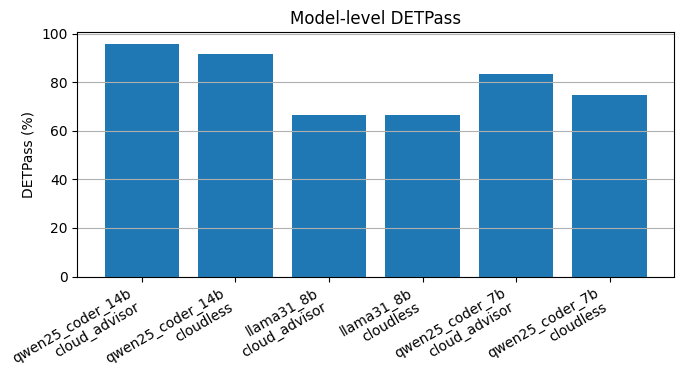

saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/figures/fig_model_pass_rate_A100_SET_B.png


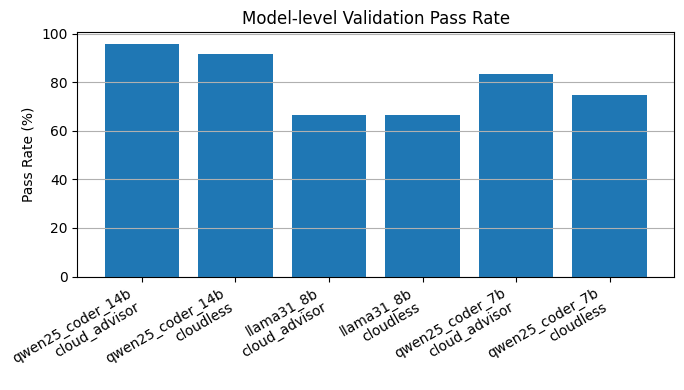

saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/figures/fig_model_prompt_tokens_A100_SET_B.png


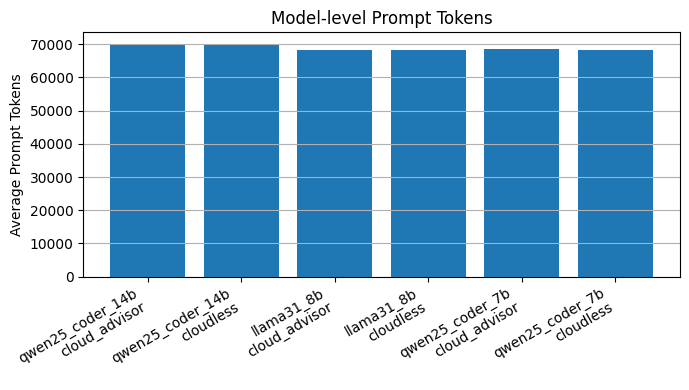

saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/figures/fig_token_comparison_A100_SET_B.png


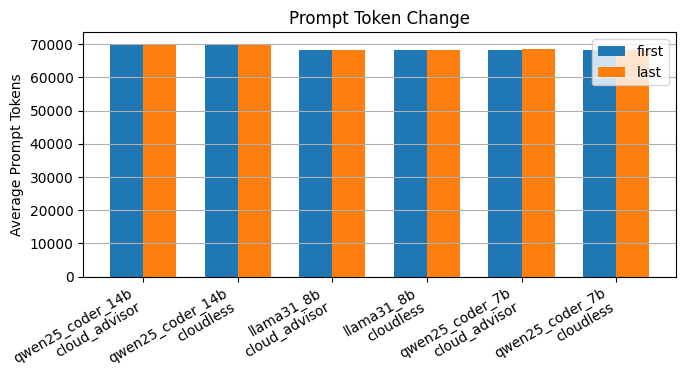

,item,reason
0,fig_model_latency_A100_SET_B.png,missing column: avg_latency_ms


{
  "server": "A100_SET_B",
  "repo": "/root/llm/JOILang-Server",
  "script": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py",
  "results_root": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results",
  "paper_artifact_root": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts",
  "generated_at": "2026-06-15T12:27:28.527322",
  "df_files_rows": 52,
  "df_final_rows": 52,
  "table_main_results_rows": 6,
  "figures_dir": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/figures",
  "tables_dir": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/tables",
  "summary_dir": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/summary",
  "skipped_count": 1
}
saved: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_artifacts/summary/paper_artifact_report_A100_SET_B.json


In [39]:
# ============================================================
# 8. MAIN TABLE + MODEL-LEVEL FIGURES
# ============================================================

import matplotlib.pyplot as plt

def select_latest_per_model_mode(df):
    if len(df) == 0:
        return df
    x = df.copy()
    x["mtime"] = x["ga_output"].map(lambda p: Path(p).stat().st_mtime if Path(p).exists() else 0)
    x["is_full_fair_like"] = x["run_name"].str.contains("ga_", na=False) & ~x["run_name"].str.contains("smoke", na=False)
    x = x.sort_values(["is_full_fair_like", "mtime"], ascending=[False, False])
    x = x.dropna(subset=["model_key", "mode"])
    return x.drop_duplicates(["model_key", "mode"], keep="first").reset_index(drop=True)

table_main_results = select_latest_per_model_mode(df_final)
main_cols = [c for c in [
    "model_key","mode","best_so_far_DETPass","validation_det_pass_rate","validation_avg_det_score",
    "first_avg_prompt_tokens","last_avg_prompt_tokens","min_avg_prompt_tokens","token_delta","token_reduction_ratio",
    "avg_latency_ms","new_by_micro_compression_sum","new_by_block_compression_sum","new_by_multi_block_compression_sum",
    "new_by_compression_fallback_sum","advisor_proposal_rows","advisor_accepted_rows","advisor_rejected_rows","ga_output"
] if c in table_main_results.columns]
table_main_results = table_main_results[main_cols]
display(table_main_results)

main_csv = TABLE_DIR / f"table_main_results_{SERVER_PRESET}.csv"
main_tex = TABLE_DIR / f"table_main_results_{SERVER_PRESET}.tex"
table_main_results.to_csv(main_csv, index=False)
try:
    table_main_results.to_latex(main_tex, index=False, float_format="%.3f")
except Exception as e:
    SKIPPED_ITEMS.append({"item": str(main_tex), "reason": f"latex export failed: {e!r}"})
print("saved:", main_csv)
print("saved:", main_tex)

def save_current_fig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)
    plt.show()

def plot_metric_bar(df, value_col, title, ylabel, filename):
    if len(df) == 0:
        SKIPPED_ITEMS.append({"item": filename, "reason": "empty table"})
        return
    if value_col not in df.columns:
        SKIPPED_ITEMS.append({"item": filename, "reason": f"missing column: {value_col}"})
        return
    d = df[["model_key", "mode", value_col]].dropna()
    if len(d) == 0:
        SKIPPED_ITEMS.append({"item": filename, "reason": f"no non-null data for {value_col}"})
        return
    d["label"] = d["model_key"].astype(str) + "\n" + d["mode"].astype(str)
    plt.figure(figsize=(max(7, len(d) * 0.8), 4))
    plt.bar(d["label"], pd.to_numeric(d[value_col], errors="coerce"))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y")
    save_current_fig(FIG_DIR / filename)

plot_metric_bar(table_main_results, "best_so_far_DETPass", "Model-level DETPass", "DETPass (%)", f"fig_model_detpass_{SERVER_PRESET}.png")
plot_metric_bar(table_main_results, "validation_det_pass_rate", "Model-level Validation Pass Rate", "Pass Rate (%)", f"fig_model_pass_rate_{SERVER_PRESET}.png")
plot_metric_bar(table_main_results, "last_avg_prompt_tokens", "Model-level Prompt Tokens", "Average Prompt Tokens", f"fig_model_prompt_tokens_{SERVER_PRESET}.png")
plot_metric_bar(table_main_results, "avg_latency_ms", "Model-level Latency", "Latency (ms)", f"fig_model_latency_{SERVER_PRESET}.png")

if {"first_avg_prompt_tokens", "last_avg_prompt_tokens", "model_key", "mode"}.issubset(table_main_results.columns):
    d = table_main_results[["model_key","mode","first_avg_prompt_tokens","last_avg_prompt_tokens"]].dropna()
    if len(d):
        labels = d["model_key"].astype(str) + "\n" + d["mode"].astype(str)
        x = np.arange(len(d))
        width = 0.35
        plt.figure(figsize=(max(7, len(d) * 0.9), 4))
        plt.bar(x - width / 2, d["first_avg_prompt_tokens"], width, label="first")
        plt.bar(x + width / 2, d["last_avg_prompt_tokens"], width, label="last")
        plt.xticks(x, labels, rotation=30, ha="right")
        plt.ylabel("Average Prompt Tokens")
        plt.title("Prompt Token Change")
        plt.grid(axis="y")
        plt.legend()
        save_current_fig(FIG_DIR / f"fig_token_comparison_{SERVER_PRESET}.png")
    else:
        SKIPPED_ITEMS.append({"item": "fig_token_comparison", "reason": "no first/last token data"})

skipped_df = pd.DataFrame(SKIPPED_ITEMS)
display(skipped_df)
skipped_df.to_csv(SUMMARY_DIR / f"skipped_items_{SERVER_PRESET}.csv", index=False)

report = {
    "server": SERVER_PRESET,
    "repo": str(REPO),
    "script": str(SCRIPT),
    "results_root": str(RESULTS_ROOT),
    "paper_artifact_root": str(PAPER_ARTIFACT_ROOT),
    "generated_at": datetime.now().isoformat(),
    "df_files_rows": int(len(df_files)),
    "df_final_rows": int(len(df_final)),
    "table_main_results_rows": int(len(table_main_results)),
    "figures_dir": str(FIG_DIR),
    "tables_dir": str(TABLE_DIR),
    "summary_dir": str(SUMMARY_DIR),
    "skipped_count": int(len(SKIPPED_ITEMS)),
}
report_path = SUMMARY_DIR / f"paper_artifact_report_{SERVER_PRESET}.json"
report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(report, ensure_ascii=False, indent=2))
print("saved:", report_path)

## Phase 2 이후 TODO

Phase 1이 통과한 뒤 순차적으로 추가하세요.

1. Pareto frontier figure
2. category-wise DET/pass/token heatmap
3. GA evolution curve
4. ablation table/figure
5. PICARD-style comparison
6. error distribution
7. judge reliability
8. A100 vs A6000 server comparison

없는 파일/컬럼은 예외가 아니라 `SKIPPED_ITEMS`로 기록하는 원칙을 유지합니다.